# Compare N Phenomenological Result Runs (with Grouping)

This notebook compares multiple agent runs, with support for grouping runs by label (e.g., all "Occam" runs share the same color but have distinct markers/linestyles).

In [76]:
import json
import glob
import re
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.figsize"] = [12, 8]
plt.rcParams["figure.dpi"] = 100

## Configuration

Define your runs as a list of dictionaries with `name`, `directory`, and `group`.

Runs with the same `group` will share the same color but have different markers/line styles.

In [77]:
RUNS = [
    # Claude Sonnet 4.5 with feedback
    {
        "name": "Claude Sonnet 4.5 with FB 1",
        "directory": "./kinetic_fitting_with_fb_claudesonnet45_1",
        "group": "Claude Sonnet 4.5 with FB",
    },
    {
        "name": "Claude Sonnet 4.5 with FB 2",
        "directory": "./kinetic_fitting_with_fb_claudesonnet45_2",
        "group": "Claude Sonnet 4.5 with FB",
    },
    {
        "name": "Claude Sonnet 4.5 with FB 3",
        "directory": "./kinetic_fitting_with_fb_claudesonnet45_3",
        "group": "Claude Sonnet 4.5 with FB",
    },
    {
        "name": "Claude Sonnet 4.5 with FB 4",
        "directory": "./kinetic_fitting_with_fb_claudesonnet45_4",
        "group": "Claude Sonnet 4.5 with FB",
    },
    {
        "name": "Claude Sonnet 4.5 with FB 5",
        "directory": "./kinetic_fitting_with_fb_claudesonnet45_5",
        "group": "Claude Sonnet 4.5 with FB",
    },
    # Claude Sonnet 4.5 no feedback
    {
        "name": "Claude Sonnet 4.5 no FB 1",
        "directory": "./kinetic_fitting_no_fb_claudesonnet45_1",
        "group": "Claude Sonnet 4.5 no FB",
    },
    {
        "name": "Claude Sonnet 4.5 no FB 2",
        "directory": "./kinetic_fitting_no_fb_claudesonnet45_2",
        "group": "Claude Sonnet 4.5 no FB",
    },
    {
        "name": "Claude Sonnet 4.5 no FB 3",
        "directory": "./kinetic_fitting_no_fb_claudesonnet45_3",
        "group": "Claude Sonnet 4.5 no FB",
    },
    {
        "name": "Claude Sonnet 4.5 no FB 4",
        "directory": "./kinetic_fitting_no_fb_claudesonnet45_4",
        "group": "Claude Sonnet 4.5 no FB",
    },
    {
        "name": "Claude Sonnet 4.5 no FB 5",
        "directory": "./kinetic_fitting_no_fb_claudesonnet45_5",
        "group": "Claude Sonnet 4.5 no FB",
    },
    # GPT-4o no feedback
    {
        "name": "GPT-4o no FB 1",
        "directory": "./kinetic_fitting_no_fb_gpt4o_feedback_1",
        "group": "GPT-4o no FB",
    },
    {
        "name": "GPT-4o no FB 2",
        "directory": "./kinetic_fitting_no_fb_gpt4o_feedback_2",
        "group": "GPT-4o no FB",
    },
    {
        "name": "GPT-4o no FB 3",
        "directory": "./kinetic_fitting_no_fb_gpt4o_feedback_3",
        "group": "GPT-4o no FB",
    },
    {
        "name": "GPT-4o no FB 4",
        "directory": "./kinetic_fitting_no_fb_gpt4o_feedback_4",
        "group": "GPT-4o no FB",
    },
    {
        "name": "GPT-4o no FB 5",
        "directory": "./kinetic_fitting_no_fb_gpt4o_feedback_5",
        "group": "GPT-4o no FB",
    },
]

## Helper Functions

In [78]:
def load_results(directory):
    """Load all phenomenological result files sorted by timestamp."""
    pattern = f"{directory}/phenomenologic_result.json.*"
    files = glob.glob(pattern)

    results = []
    for filepath in files:
        match = re.search(r"phenomenologic_result\.json\.(\d+)$", filepath)
        if not match:
            continue

        timestamp = int(match.group(1))

        try:
            with open(filepath, "r") as f:
                data = json.load(f)

            results.append(
                {
                    "timestamp": timestamp,
                    "datetime": datetime.fromtimestamp(timestamp),
                    "filepath": filepath,
                    "data": data,
                }
            )
        except (json.JSONDecodeError, IOError) as e:
            print(f"Warning: Could not read {filepath}: {e}")
            continue

    results.sort(key=lambda x: x["timestamp"])
    return results


def extract_reactions_set(data):
    """Extract set of reaction equations from result data."""
    if "network" not in data or "reactions" not in data["network"]:
        return set()
    return {r["equation"] for r in data["network"]["reactions"]}


def extract_reactions_list(data):
    """Extract list of reactions with full details."""
    if "network" not in data or "reactions" not in data["network"]:
        return []
    return data["network"]["reactions"]


def build_dataframe(results, run_name, group_name):
    """Convert results to a pandas DataFrame."""
    if not results:
        return pd.DataFrame()

    rows = []
    prev_reactions = set()
    prev_best = 0

    for i, r in enumerate(results):
        trends = r["data"].get("phenomenological_trends", {})
        components = trends.get("components", {})
        curr_reactions = extract_reactions_set(r["data"])

        overall_score = trends.get("overall_score", 0)
        is_improvement = overall_score > prev_best

        row = {
            "run_name": run_name,
            "group": group_name,
            "run_idx": i + 1,
            "timestamp": r["timestamp"],
            "datetime": r["datetime"],
            "elapsed_minutes": (r["timestamp"] - results[0]["timestamp"]) / 60,
            "overall_score": overall_score,
            "best_score": r["data"].get("best_phenomenological_score", 0),
            "ru_score": trends.get("ru_score", 0),
            "s2o8_score": trends.get("s2o8_score", 0),
            "irradiance_score": trends.get("irradiance_score", 0),
            "ph_score": trends.get("pH_score", 0),
            "ru_shape": components.get("ru_shape", 0),
            "ru_mag": components.get("ru_mag", 0),
            "s2o8_shape": components.get("s2o8_shape", 0),
            "s2o8_mag": components.get("s2o8_mag", 0),
            "n_reactions": len(curr_reactions),
            "is_improvement": is_improvement,
            "improvement_delta": overall_score - prev_best if is_improvement else 0,
        }
        rows.append(row)

        if is_improvement:
            prev_best = overall_score
        prev_reactions = curr_reactions

    return pd.DataFrame(rows)

## Style Configuration

In [79]:
# Color palette for groups
GROUP_COLORS = {
    "Without Occams": "#1f77b4",  # Blue
    "GPT-4o no FB": "#ff7f0e",  # Orange
    "Claude Sonnet 4.5 with FB": "#2ca02c",  # Green
    "Claude Sonnet 4.5 no FB": "#9467bd",  # Purple
    "Default": "#7f7f7f",  # Gray
}

# Distinct markers for runs within a group
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<", ">", "p"]

# Distinct line styles for runs within a group
LINE_STYLES = ["-"] * 10


def get_group_color(group_name):
    """Get color for a group, with fallback."""
    return GROUP_COLORS.get(group_name, GROUP_COLORS["Default"])


def build_style_map(runs):
    """Build a mapping of run_name -> (color, marker, linestyle) with unique styles per run."""
    # Group runs by their group
    groups = defaultdict(list)
    for run in runs:
        groups[run["group"]].append(run["name"])

    style_map = {}
    for group_name, run_names in groups.items():
        color = get_group_color(group_name)
        for i, run_name in enumerate(run_names):
            marker = MARKERS[i % len(MARKERS)]
            linestyle = LINE_STYLES[i % len(LINE_STYLES)]
            style_map[run_name] = {
                "color": color,
                "marker": marker,
                "linestyle": linestyle,
                "group": group_name,
                "idx": i,
            }

    return style_map


STYLE_MAP = build_style_map(RUNS)

# Print style assignments to verify
print("Style assignments:")
print("-" * 80)
for name, style in STYLE_MAP.items():
    ls_str = style["linestyle"] if isinstance(style["linestyle"], str) else "custom"
    print(
        f"  {name:<20} | {style['group']:<15} | marker='{style['marker']}' | linestyle='{ls_str}'"
    )

Style assignments:
--------------------------------------------------------------------------------
  Claude Sonnet 4.5 with FB 1 | Claude Sonnet 4.5 with FB | marker='o' | linestyle='-'
  Claude Sonnet 4.5 with FB 2 | Claude Sonnet 4.5 with FB | marker='s' | linestyle='-'
  Claude Sonnet 4.5 with FB 3 | Claude Sonnet 4.5 with FB | marker='^' | linestyle='-'
  Claude Sonnet 4.5 with FB 4 | Claude Sonnet 4.5 with FB | marker='D' | linestyle='-'
  Claude Sonnet 4.5 with FB 5 | Claude Sonnet 4.5 with FB | marker='v' | linestyle='-'
  Claude Sonnet 4.5 no FB 1 | Claude Sonnet 4.5 no FB | marker='o' | linestyle='-'
  Claude Sonnet 4.5 no FB 2 | Claude Sonnet 4.5 no FB | marker='s' | linestyle='-'
  Claude Sonnet 4.5 no FB 3 | Claude Sonnet 4.5 no FB | marker='^' | linestyle='-'
  Claude Sonnet 4.5 no FB 4 | Claude Sonnet 4.5 no FB | marker='D' | linestyle='-'
  Claude Sonnet 4.5 no FB 5 | Claude Sonnet 4.5 no FB | marker='v' | linestyle='-'
  GPT-4o no FB 1       | GPT-4o no FB    | marker=

## Load All Runs

In [80]:
# Load all runs
all_results = {}
all_dfs = {}

for run in RUNS:
    name = run["name"]
    directory = run["directory"]
    group = run["group"]

    results = load_results(directory)
    all_results[name] = results
    all_dfs[name] = build_dataframe(results, name, group)

    n_files = len(results)
    if n_files > 0:
        duration = (results[-1]["timestamp"] - results[0]["timestamp"]) / 60
        print(f"[{group}] {name}: {n_files} files, {duration:.1f} min")
    else:
        print(f"[{group}] {name}: No files found in {directory}")

# Combined dataframe
df_combined = pd.concat(
    [df for df in all_dfs.values() if len(df) > 0], ignore_index=True
)
print(f"\nTotal: {len(df_combined)} evaluations across {len(RUNS)} runs")

[Claude Sonnet 4.5 with FB] Claude Sonnet 4.5 with FB 1: 17 files, 268.7 min
[Claude Sonnet 4.5 with FB] Claude Sonnet 4.5 with FB 2: 15 files, 103.5 min
[Claude Sonnet 4.5 with FB] Claude Sonnet 4.5 with FB 3: 8 files, 56.4 min
[Claude Sonnet 4.5 with FB] Claude Sonnet 4.5 with FB 4: 12 files, 100.8 min
[Claude Sonnet 4.5 with FB] Claude Sonnet 4.5 with FB 5: 20 files, 250.1 min
[Claude Sonnet 4.5 no FB] Claude Sonnet 4.5 no FB 1: 31 files, 414.9 min
[Claude Sonnet 4.5 no FB] Claude Sonnet 4.5 no FB 2: 17 files, 450.4 min
[Claude Sonnet 4.5 no FB] Claude Sonnet 4.5 no FB 3: 11 files, 173.3 min
[Claude Sonnet 4.5 no FB] Claude Sonnet 4.5 no FB 4: 20 files, 150.6 min
[Claude Sonnet 4.5 no FB] Claude Sonnet 4.5 no FB 5: 17 files, 67.0 min
[GPT-4o no FB] GPT-4o no FB 1: 1 files, 0.0 min
[GPT-4o no FB] GPT-4o no FB 2: 5 files, 26.1 min
[GPT-4o no FB] GPT-4o no FB 3: 41 files, 115.2 min
[GPT-4o no FB] GPT-4o no FB 4: 30 files, 1980.5 min
[GPT-4o no FB] GPT-4o no FB 5: 6 files, 26.9 min

Tot

## Summary Table

In [81]:
def get_run_summary(name, df, results, group):
    """Generate summary statistics for a run."""
    if len(df) == 0:
        return {
            "Run": name,
            "Group": group,
            "Evaluations": 0,
            "Improvements": 0,
            "Best Score": 0,
            "Final Score": 0,
            "Best Ru": 0,
            "Best S2O8": 0,
            "Best Irradiance": 0,
            "Best pH": 0,
            "Best Network Size": 0,
            "Duration (min)": 0,
            "Efficiency (%)": 0,
        }

    best_idx = df["overall_score"].idxmax()
    best_row = df.loc[best_idx]

    return {
        "Run": name,
        "Group": group,
        "Evaluations": len(df),
        "Improvements": int(df["is_improvement"].sum()),
        "Best Score": df["overall_score"].max(),
        "Final Score": df.iloc[-1]["overall_score"],
        "Best Ru": df["ru_score"].max(),
        "Best S2O8": df["s2o8_score"].max(),
        "Best Irradiance": df["irradiance_score"].max(),
        "Best pH": df["ph_score"].max(),
        "Best Network Size": int(best_row["n_reactions"]),
        "Duration (min)": df["elapsed_minutes"].max(),
        "Efficiency (%)": df["is_improvement"].sum() / len(df) * 100,
    }


summaries = []
for run in RUNS:
    name = run["name"]
    group = run["group"]
    summaries.append(get_run_summary(name, all_dfs[name], all_results[name], group))

summary_df = pd.DataFrame(summaries)

print("=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
display(summary_df.round(4))

SUMMARY TABLE


,Run,Group,Evaluations,Improvements,Best Score,Final Score,Best Ru,Best S2O8,Best Irradiance,Best pH,Best Network Size,Duration (min),Efficiency (%)
0,Claude Sonnet 4.5 with FB 1,Claude Sonnet 4.5 with FB,17,4,0.6918,0.6918,0.5863,0.6912,0.9973,0.6137,10,268.6667,23.5294
1,Claude Sonnet 4.5 with FB 2,Claude Sonnet 4.5 with FB,15,3,0.8276,0.8276,0.9642,0.7606,0.9470,0.5860,7,103.5000,20.0000
2,Claude Sonnet 4.5 with FB 3,Claude Sonnet 4.5 with FB,8,4,0.7586,0.7586,0.7766,0.7506,0.9935,0.5881,7,56.4167,50.0000
3,Claude Sonnet 4.5 with FB 4,Claude Sonnet 4.5 with FB,12,5,0.7530,0.7530,0.9234,0.6062,0.7983,0.5144,8,100.8167,41.6667
4,Claude Sonnet 4.5 with FB 5,Claude Sonnet 4.5 with FB,20,6,0.7105,0.7105,0.5968,0.7863,0.9720,0.6089,10,250.0500,30.0000
5,Claude Sonnet 4.5 no FB 1,Claude Sonnet 4.5 no FB,31,6,0.6888,0.5834,0.8078,0.9917,0.8047,0.7474,9,414.9000,19.3548
6,Claude Sonnet 4.5 no FB 2,Claude Sonnet 4.5 no FB,17,5,0.5619,0.1256,0.5267,0.9482,0.6608,0.7175,10,450.4500,29.4118
7,Claude Sonnet 4.5 no FB 3,Claude Sonnet 4.5 no FB,11,1,0.6276,0.2499,0.5694,0.6636,0.8174,0.5182,6,173.3500,9.0909
8,Claude Sonnet 4.5 no FB 4,Claude Sonnet 4.5 no FB,20,5,0.5696,0.0000,0.8371,0.9688,0.3374,0.6197,7,150.5833,25.0000
9,Claude Sonnet 4.5 no FB 5,Claude Sonnet 4.5 no FB,17,2,0.6308,0.0099,0.4643,0.9721,0.7028,0.7170,5,67.0500,11.7647


## Group Summary

In [82]:
# Aggregate by group
group_summary = (
    summary_df.groupby("Group")
    .agg(
        {
            "Evaluations": "sum",
            "Improvements": "sum",
            "Best Score": "max",
            "Best Ru": "max",
            "Best S2O8": "max",
            "Best Irradiance": "max",
            "Best pH": "max",
            "Best Network Size": "min",
            "Efficiency (%)": "mean",
        }
    )
    .round(4)
)

group_summary["Num Runs"] = summary_df.groupby("Group").size()

print("=" * 80)
print("GROUP SUMMARY (aggregated across runs in each group)")
print("=" * 80)
display(group_summary)

GROUP SUMMARY (aggregated across runs in each group)


,Evaluations,Improvements,Best Score,Best Ru,Best S2O8,Best Irradiance,Best pH,Best Network Size,Efficiency (%),Num Runs
Group,,,,,,,,,,
Claude Sonnet 4.5 no FB,96,19,0.6888,0.8371,0.9917,0.8174,0.7474,5,18.9244,5
Claude Sonnet 4.5 with FB,72,22,0.8276,0.9642,0.7863,0.9973,0.6137,7,33.0392,5
GPT-4o no FB,83,7,0.6353,0.7095,0.7752,0.8279,0.6310,6,33.1545,5


## Plot 1: Best Score Progression Over Time (Grouped)

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

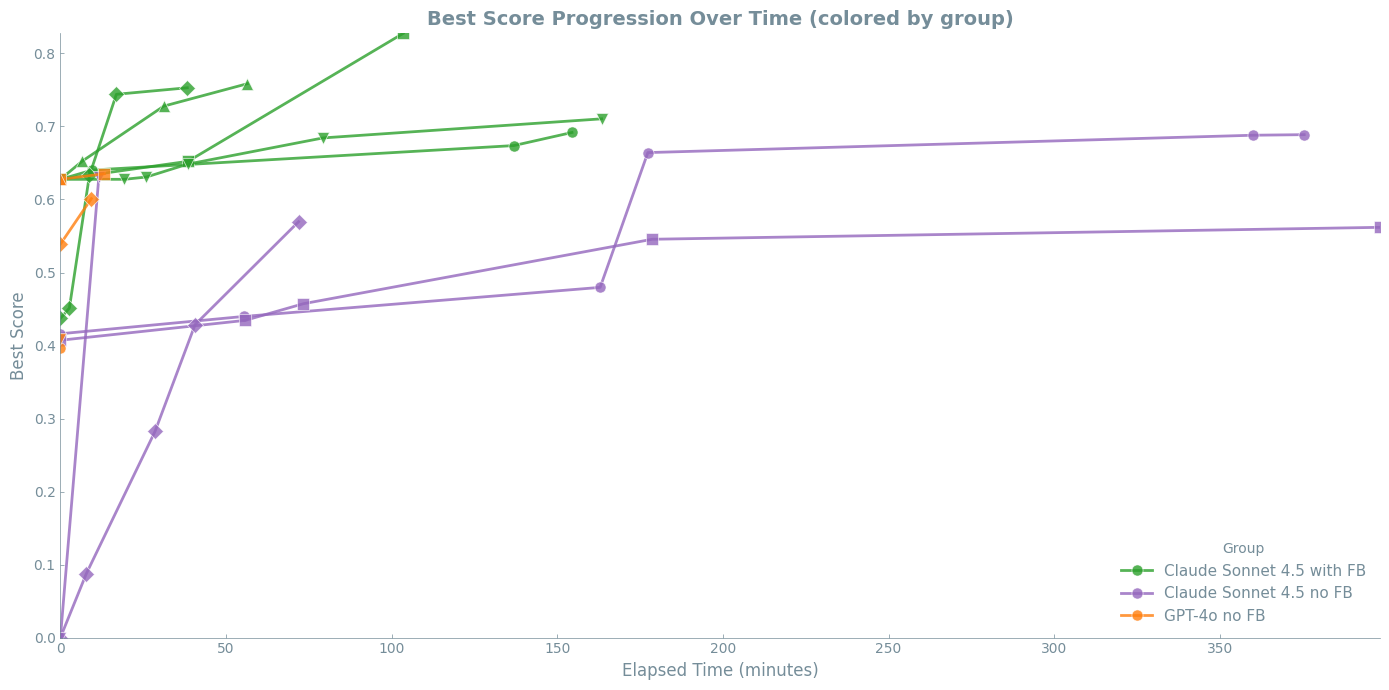

In [83]:
fig, ax = plt.subplots(figsize=(14, 7))

group_in_legend = set()

for name, df in all_dfs.items():
    if len(df) == 0:
        continue

    style = STYLE_MAP[name]
    improvements = df[df["is_improvement"]]

    if len(improvements) > 0:
        label = style["group"] if style["group"] not in group_in_legend else None
        if label:
            group_in_legend.add(style["group"])

        ax.plot(
            improvements["elapsed_minutes"],
            improvements["overall_score"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            alpha=0.8,
            label=label,
            markeredgecolor="white",
            markeredgewidth=0.5,
        )

ax.set_xlabel("Elapsed Time (minutes)", fontsize=12)
ax.set_ylabel("Best Score", fontsize=12)
ax.set_title(
    "Best Score Progression Over Time (colored by group)",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=11, title="Group")
# ax.grid(True, alpha=0.3)
# ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [84]:
all_dfs

{'Claude Sonnet 4.5 with FB 1':                        run_name                      group  run_idx  \
 0   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        1   
 1   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        2   
 2   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        3   
 3   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        4   
 4   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        5   
 5   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        6   
 6   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        7   
 7   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        8   
 8   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        9   
 9   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB       10   
 10  Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB       11   
 11  Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB       12   
 12  Claude Sonnet 4.5 with FB 1 

## Plot 2: Best Score vs Evaluation Number (Grouped)

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

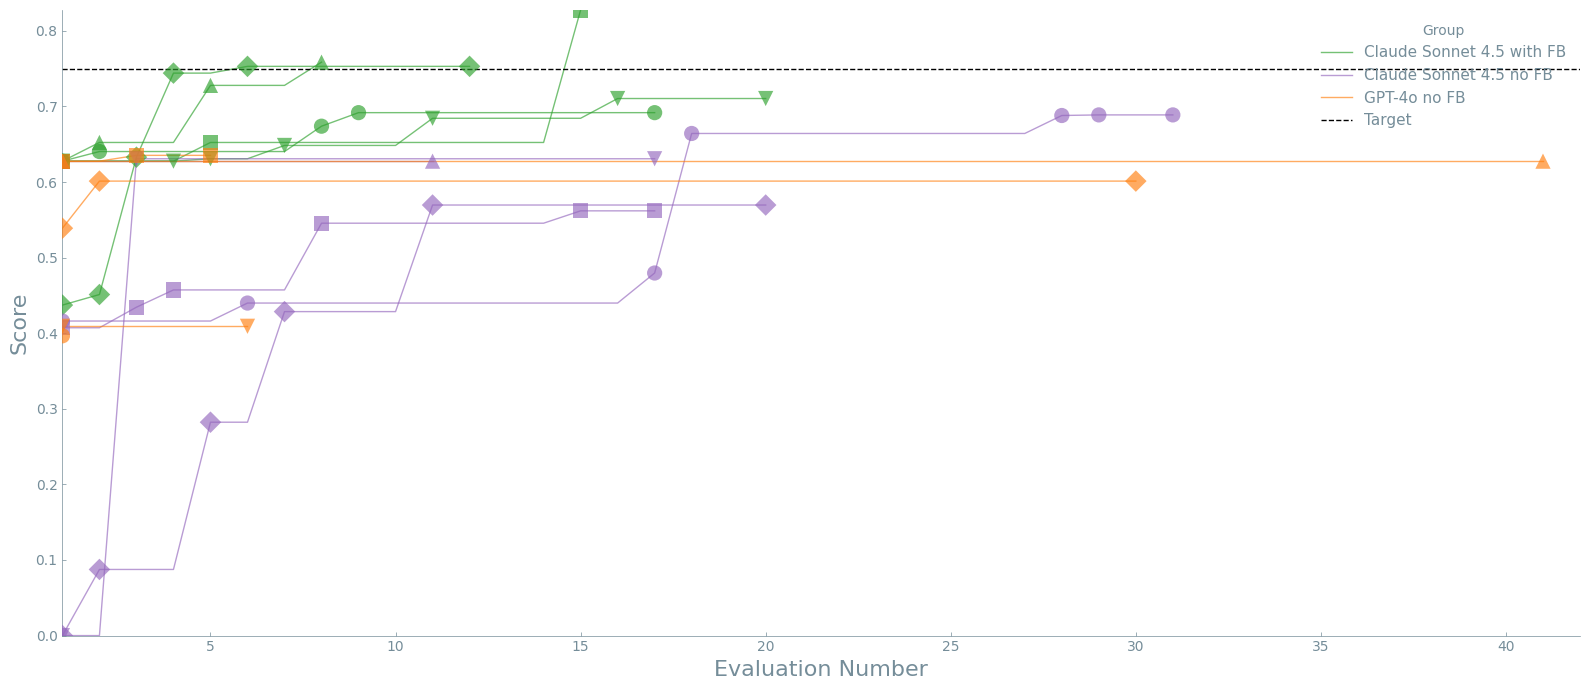

In [85]:
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(16, 7))

group_in_legend = set()

for name, df in all_dfs.items():
    if len(df) == 0:
        continue

    style = STYLE_MAP[name]
    label = style["group"] if style["group"] not in group_in_legend else None
    if label:
        group_in_legend.add(style["group"])

    # Plot the line without markers
    ax.plot(
        df["run_idx"],
        df["best_score"],
        linestyle=style["linestyle"],
        color=style["color"],
        linewidth=1,
        alpha=0.65,
        label=label,
    )

    # Only add markers where the value changes
    scores = df["best_score"].values
    run_idx = df["run_idx"].values

    # Find indices where value changes (including first and last point)
    change_mask = np.concatenate([[True], np.diff(scores) != 0])
    change_mask[-1] = True  # Always include the last point

    ax.scatter(
        run_idx[change_mask],
        scores[change_mask],
        marker=style["marker"],
        color=style["color"],
        s=120,  # markersize=7 squared for scatter
        alpha=0.65,
        edgecolors="none",
        zorder=3,
    )

ax.set_xlabel("Evaluation Number", fontsize=16)
ax.set_ylabel("Score", fontsize=16)
ax.hlines(0.75, xmin=1, xmax=42, label="Target", color="black", linestyle="--")
plt.rc("xtick", labelsize=14)
plt.rc("ytick", labelsize=14)
sns.despine()
ax.legend(fontsize=11, title="Group")
ax.grid(True, alpha=0)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

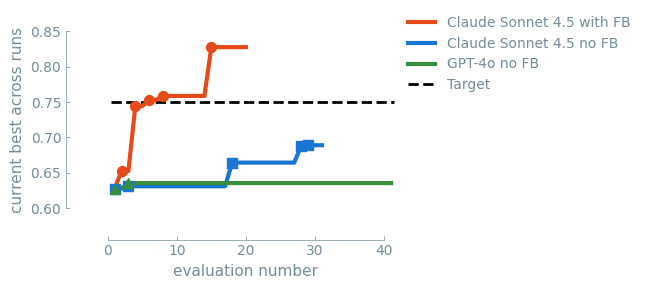

In [86]:
import lama_aesthetics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lama_aesthetics.aesthetics import golden
from lama_aesthetics.plotutils import add_identity, range_frame, ylabel_top

lama_aesthetics.get_style("main")

# =============================================================================
# STYLE CONFIGURATION
# =============================================================================

GROUP_STYLES = {
    "Claude Sonnet 4.5 with FB": {
        "color": "#E64A19",
        "linestyle": "-",
        "marker": "o",
    },
    "Claude Sonnet 4.5 no FB": {
        "color": "#1976D2",
        "linestyle": "-",
        "marker": "s",
    },
    "GPT-4o no FB": {
        "color": "#388E3C",
        "linestyle": "-",
        "marker": "^",
    },
}

# =============================================================================
# DATA PROCESSING
# =============================================================================

# Concatenate all non-empty dataframes
all_data = pd.concat([df for df in all_dfs.values() if len(df) > 0], ignore_index=True)

# For each run, forward-fill only to that GROUP's max run_idx
expanded_data = []

for group_name in all_data["group"].unique():
    group_data = all_data[all_data["group"] == group_name]
    max_run_idx_group = group_data["run_idx"].max()
    
    for run_name in group_data["run_name"].unique():
        run_data = group_data[group_data["run_name"] == run_name].sort_values("run_idx")

        # Create complete index from 1 to this group's max
        complete_idx = pd.DataFrame({"run_idx": range(1, max_run_idx_group + 1)})

        # Merge and forward fill
        run_complete = complete_idx.merge(
            run_data[["run_idx", "best_score"]], on="run_idx", how="left"
        )
        run_complete["best_score"] = run_complete["best_score"].ffill()
        run_complete["run_name"] = run_name
        run_complete["group"] = group_name

        expanded_data.append(run_complete)

all_data_expanded = pd.concat(expanded_data, ignore_index=True)

# Compute group max across all runs
group_stats = (
    all_data_expanded.groupby(["group", "run_idx"])["best_score"].max().reset_index()
)
group_stats.columns = ["group", "run_idx", "max_score"]

# =============================================================================
# PLOTTING
# =============================================================================

fig, ax = plt.subplots(figsize=(golden * 4, 3))

# Draw each group
for group_name in GROUP_STYLES:  # noqa: PLC0206
    if group_name not in group_stats["group"].values:  # noqa: PD011
        continue

    gdata = group_stats[group_stats["group"] == group_name].sort_values("run_idx")
    style = GROUP_STYLES[group_name]

    x = gdata["run_idx"].values  # noqa: PD011
    y_max = gdata["max_score"].values  # noqa: PD011

    # Find where new max occurs (score increases from previous)
    new_max_mask = np.diff(y_max, prepend=-np.inf) > 0

    # Draw line without markers
    ax.plot(
        x,
        y_max,
        color=style["color"],
        linewidth=3,
        label=group_name,
        zorder=3,
    )

    # Add markers only at new max points
    ax.scatter(
        x[new_max_mask],
        y_max[new_max_mask],
        color=style["color"],
        marker=style["marker"],
        s=50,
        zorder=4,
    )

# =============================================================================
# PLOT STYLING
# =============================================================================

max_run_idx = group_stats["run_idx"].max()
ax.hlines(
    0.75,
    xmin=0.5,
    xmax=max_run_idx + 0.5,
    label="Target",
    color="black",
    linestyle="--",
    linewidth=2,
    zorder=2,
)

ax.set_xlabel("evaluation number")
ax.set_ylabel("current best across runs")
ax.tick_params(axis="both")

ax.set_xlim(0.5, max_run_idx + 0.5)
# ax.set_ylim(0, 1)
range_frame(ax=ax, y=np.array([0.6, 0.85]), x=np.array([0, 40]))

sns.despine()
ax.legend(bbox_to_anchor=(0.95, 1.05))
fig.tight_layout()

fig.savefig("final_agent_results.pdf", dpi=300)

In [87]:
all_dfs

{'Claude Sonnet 4.5 with FB 1':                        run_name                      group  run_idx  \
 0   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        1   
 1   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        2   
 2   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        3   
 3   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        4   
 4   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        5   
 5   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        6   
 6   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        7   
 7   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        8   
 8   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB        9   
 9   Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB       10   
 10  Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB       11   
 11  Claude Sonnet 4.5 with FB 1  Claude Sonnet 4.5 with FB       12   
 12  Claude Sonnet 4.5 with FB 1 

## Plot 3: Individual Trend Scores (Grouped)

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

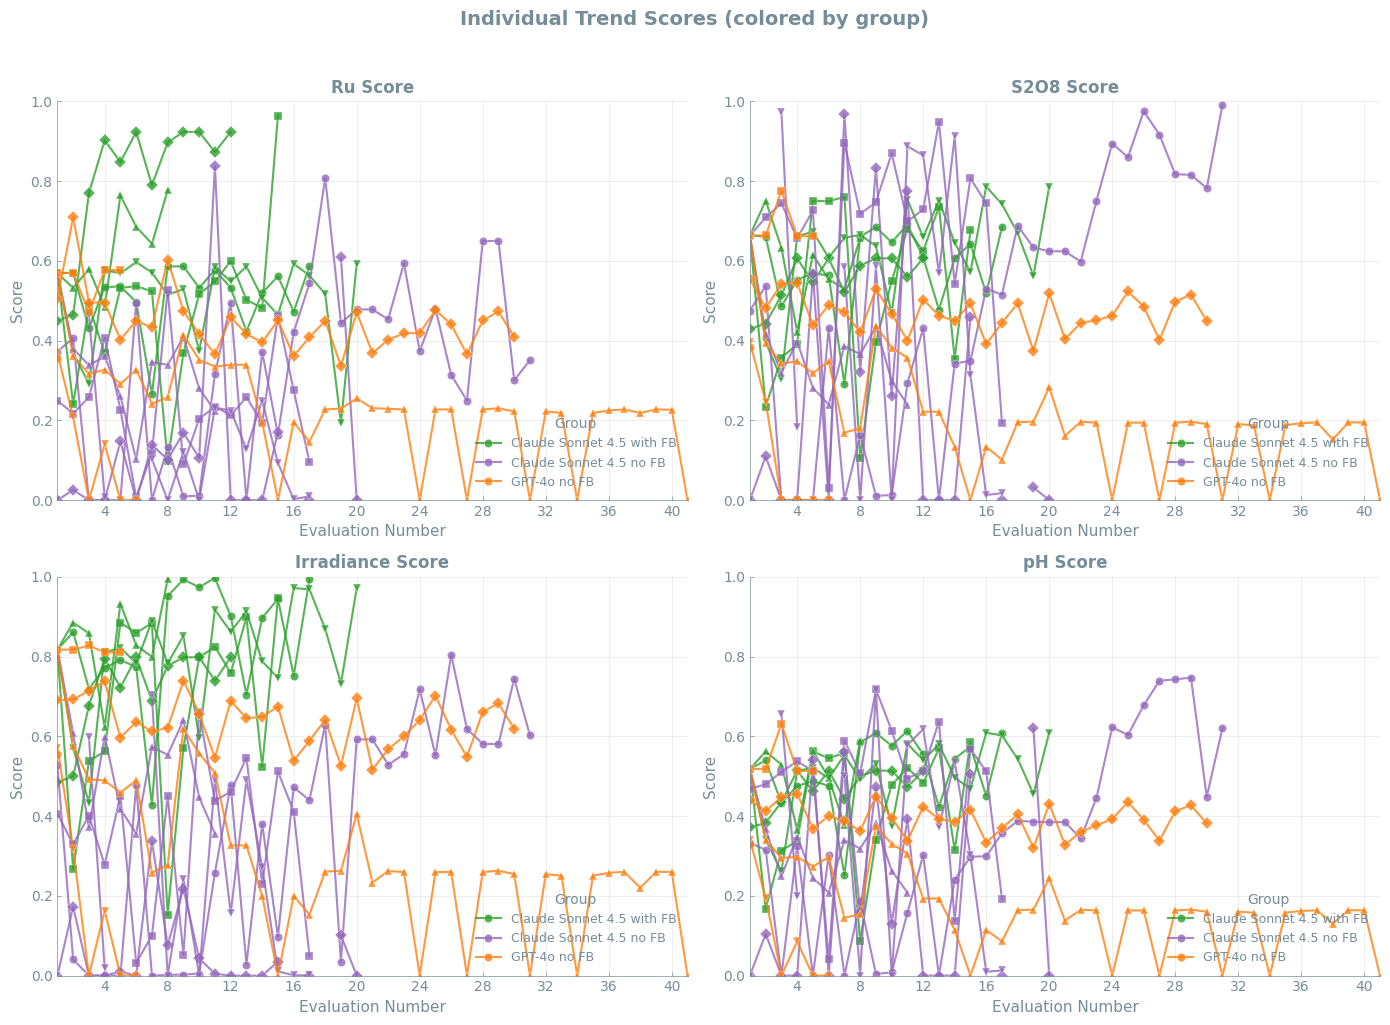

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

score_cols = [
    ("ru_score", "Ru Score"),
    ("s2o8_score", "S2O8 Score"),
    ("irradiance_score", "Irradiance Score"),
    ("ph_score", "pH Score"),
]

for ax, (col, title) in zip(axes.flat, score_cols):
    group_in_legend = set()

    for name, df in all_dfs.items():
        if len(df) == 0:
            continue

        style = STYLE_MAP[name]
        label = style["group"] if style["group"] not in group_in_legend else None
        if label:
            group_in_legend.add(style["group"])

        ax.plot(
            df["run_idx"],
            df[col],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            markersize=6,
            linewidth=1.5,
            alpha=0.8,
            label=label,
            markeredgecolor="white",
            markeredgewidth=0.3,
        )

    ax.set_xlabel("Evaluation Number")
    ax.set_ylabel("Score")
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9, title="Group")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle(
    "Individual Trend Scores (colored by group)", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

## Plot 3b: Individual Trend Scores (All Runs Labeled)

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

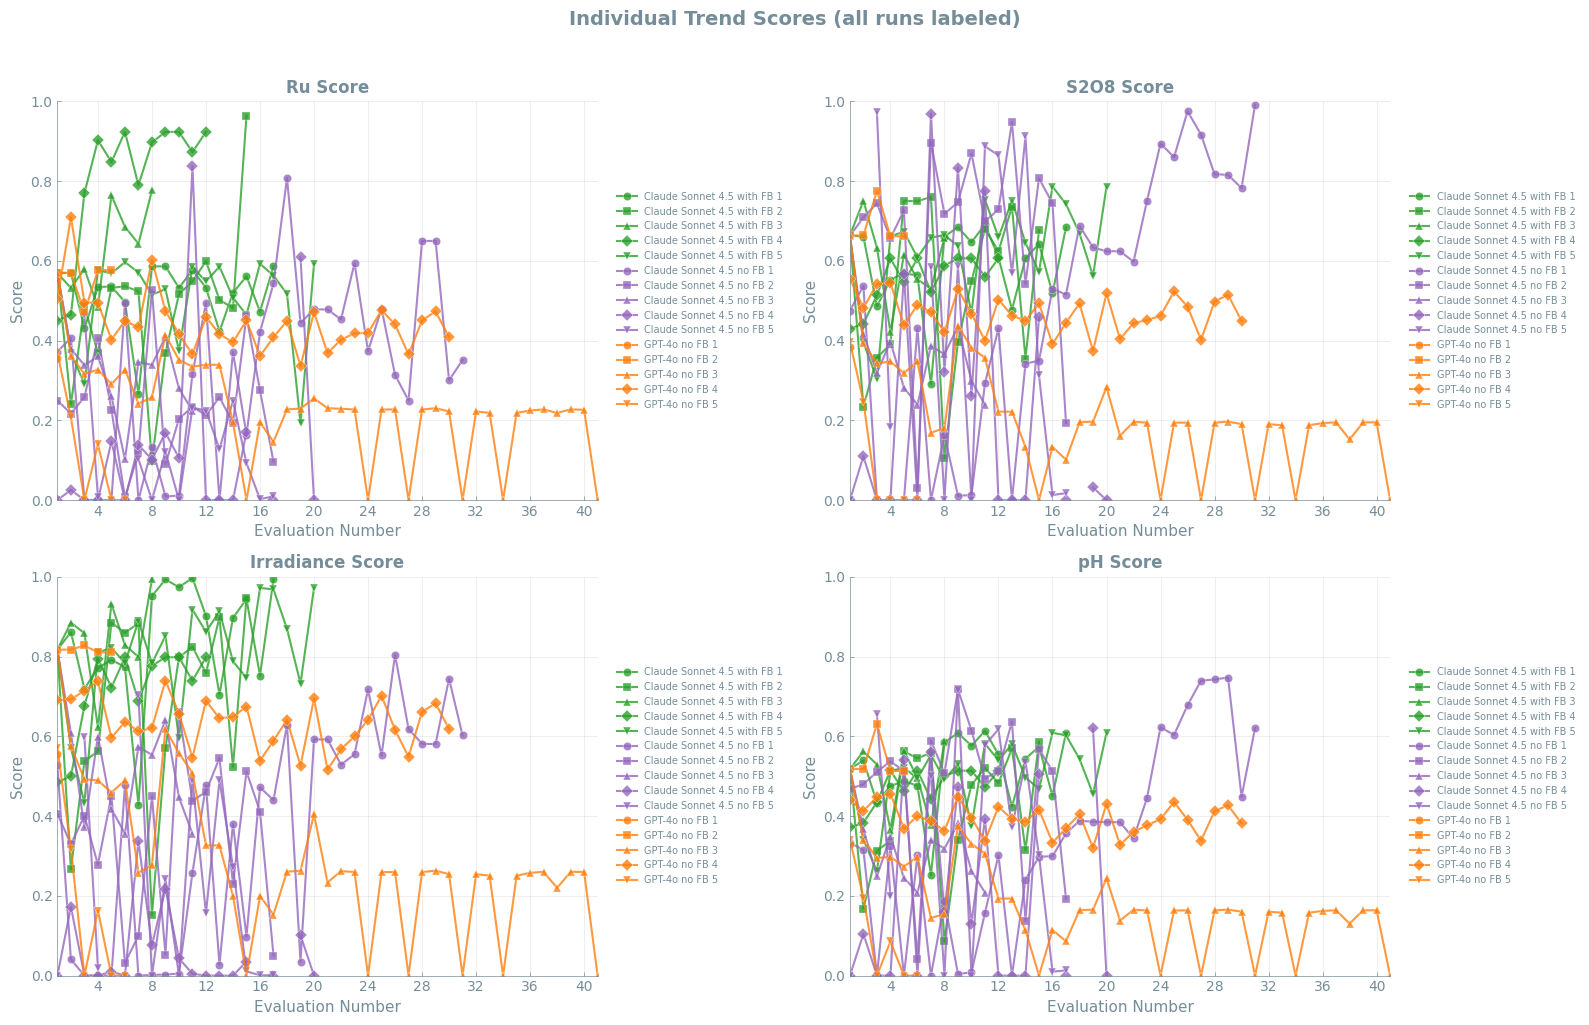

In [89]:
# Alternative version showing all individual run names in legend
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

score_cols = [
    ("ru_score", "Ru Score"),
    ("s2o8_score", "S2O8 Score"),
    ("irradiance_score", "Irradiance Score"),
    ("ph_score", "pH Score"),
]

for ax, (col, title) in zip(axes.flat, score_cols):
    for name, df in all_dfs.items():
        if len(df) == 0:
            continue

        style = STYLE_MAP[name]

        ax.plot(
            df["run_idx"],
            df[col],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            markersize=6,
            linewidth=1.5,
            alpha=0.8,
            label=name,
            markeredgecolor="white",
            markeredgewidth=0.3,
        )

    ax.set_xlabel("Evaluation Number")
    ax.set_ylabel("Score")
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle(
    "Individual Trend Scores (all runs labeled)", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

## Plot 4: Radar Chart by Group (Best per Group)

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

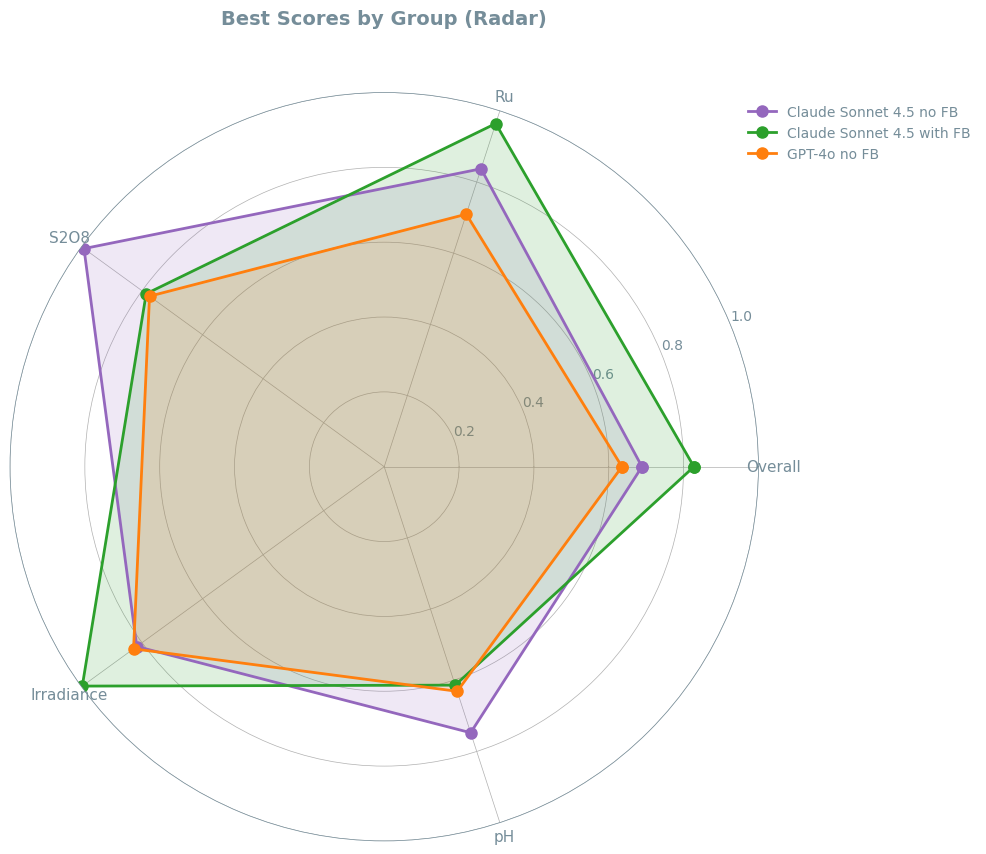

In [90]:
categories = ["Overall", "Ru", "S2O8", "Irradiance", "pH"]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

groups = group_summary.index.tolist()

for group_name in groups:
    color = get_group_color(group_name)

    scores = [
        group_summary.loc[group_name, "Best Score"],
        group_summary.loc[group_name, "Best Ru"],
        group_summary.loc[group_name, "Best S2O8"],
        group_summary.loc[group_name, "Best Irradiance"],
        group_summary.loc[group_name, "Best pH"],
    ]
    scores += scores[:1]

    ax.plot(
        angles, scores, "-o", color=color, linewidth=2, label=group_name, markersize=8
    )
    ax.fill(angles, scores, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Best Scores by Group (Radar)", fontsize=14, fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

## Plot 5: Best Scores Bar Chart by Group

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

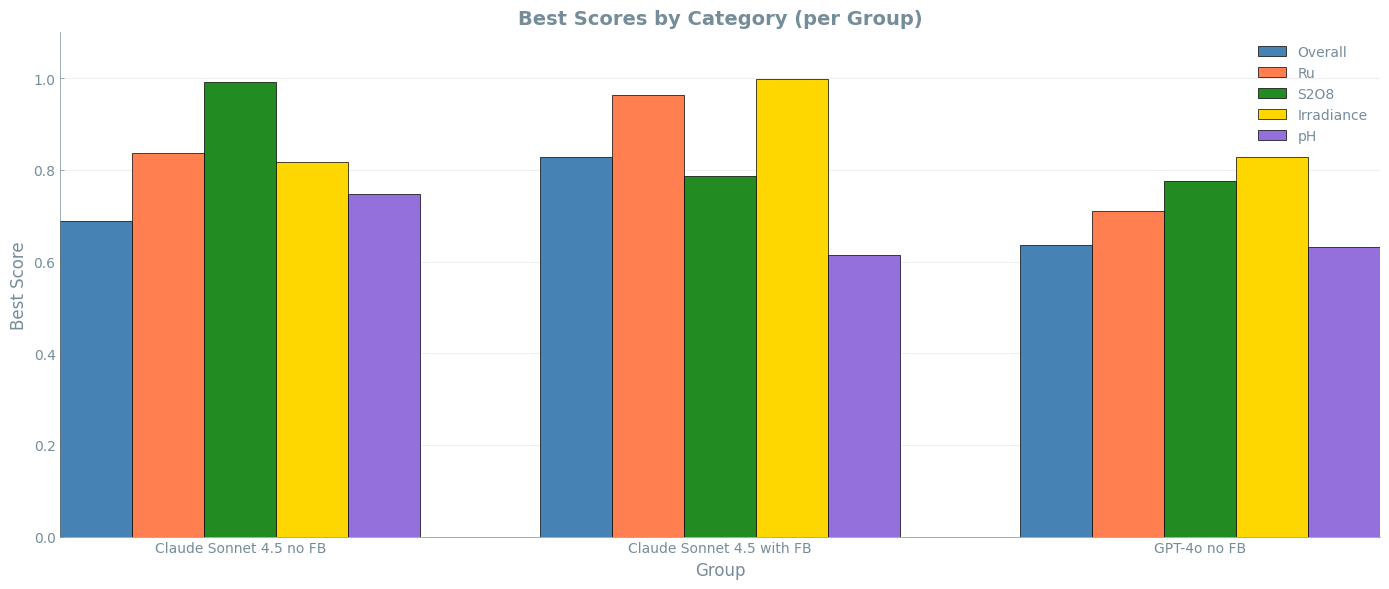

In [91]:
fig, ax = plt.subplots(figsize=(14, 6))

groups = group_summary.index.tolist()
x = np.arange(len(groups))
width = 0.15

score_types = [
    ("Best Score", "Overall"),
    ("Best Ru", "Ru"),
    ("Best S2O8", "S2O8"),
    ("Best Irradiance", "Irradiance"),
    ("Best pH", "pH"),
]

bar_colors = ["steelblue", "coral", "forestgreen", "gold", "mediumpurple"]

for j, (col, label) in enumerate(score_types):
    scores = [group_summary.loc[g, col] for g in groups]
    offset = (j - 2) * width
    ax.bar(
        x + offset,
        scores,
        width,
        label=label,
        color=bar_colors[j],
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xlabel("Group", fontsize=12)
ax.set_ylabel("Best Score", fontsize=12)
ax.set_title("Best Scores by Category (per Group)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Plot 6: Network Size vs Score (Grouped)

/tmp/ipykernel_3848116/444247622.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, "overall_score"))
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, 

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

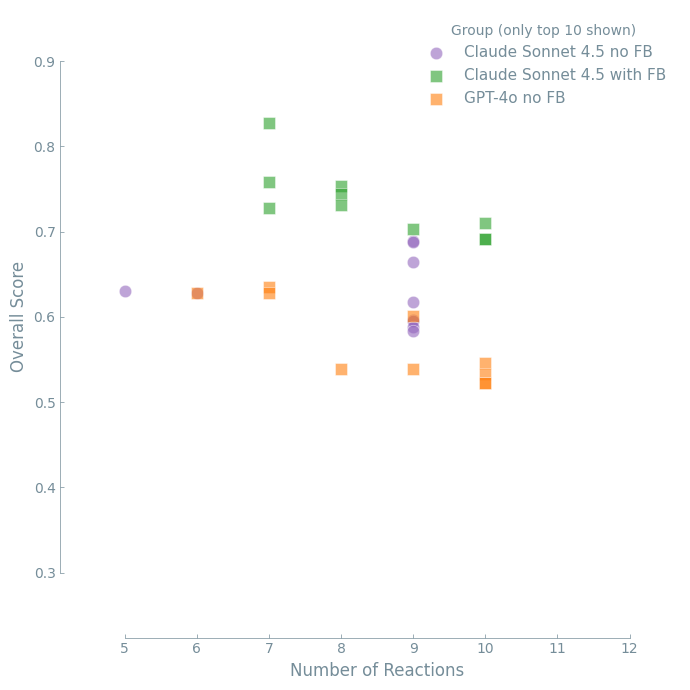

In [92]:
fig, ax = plt.subplots(figsize=(7, 7))

# Collect all entries with their group info
all_entries = []
for name, df in all_dfs.items():
    if len(df) == 0:
        continue
    style = STYLE_MAP[name]
    for idx, row in df.iterrows():
        all_entries.append(
            {
                "name": name,
                "group": style["group"],
                "n_reactions": row["n_reactions"],
                "overall_score": row["overall_score"],
                "color": style["color"],
                "marker": style["marker"],
            }
        )

# Convert to DataFrame
entries_df = pd.DataFrame(all_entries)

# Drop duplicates on (group, overall_score, n_reactions), then get top 10 per group
top_10_per_group = (
    entries_df.drop_duplicates(subset=["group", "overall_score", "n_reactions"])
    .groupby("group")
    .apply(lambda x: x.nlargest(10, "overall_score"))
    .reset_index(drop=True)
)

# Plot
for group in top_10_per_group["group"].unique():
    group_data = top_10_per_group[top_10_per_group["group"] == group]
    ax.scatter(
        group_data["n_reactions"],
        group_data["overall_score"],
        c=group_data["color"].iloc[0],
        marker=group_data["marker"].iloc[0],
        s=80,
        alpha=0.6,
        label=group,
        edgecolors="white",
        linewidths=0.5,
    )

sns.despine()

ax.set_xlabel("Number of Reactions", fontsize=12)
ax.set_ylabel("Overall Score", fontsize=12)
# ax.set_title("Network Size vs Score (colored by group)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, title="Group (only top 10 shown)")
# ax.grid(True, alpha=0.3)

range_frame(ax,y=np.array([0.3,0.9]), x=np.array([5,12]))
plt.tight_layout()
plt.show()

## Plot 7: Improvement Efficiency by Group

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

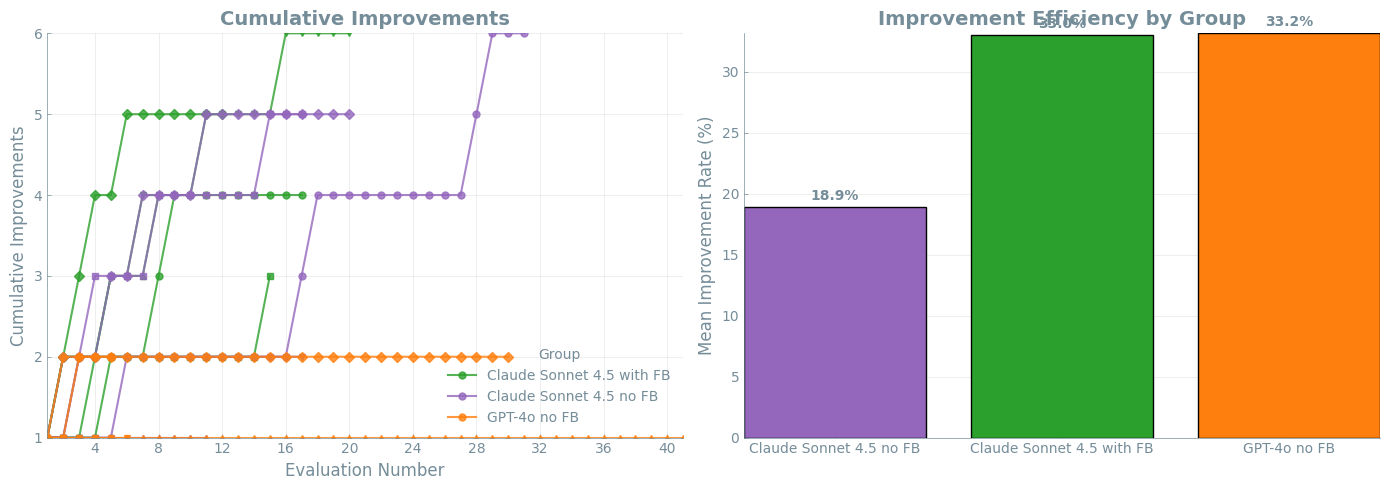

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative improvements (by group)
ax1 = axes[0]
group_in_legend = set()

for name, df in all_dfs.items():
    if len(df) == 0:
        continue

    style = STYLE_MAP[name]
    label = style["group"] if style["group"] not in group_in_legend else None
    if label:
        group_in_legend.add(style["group"])

    cumsum = df["is_improvement"].cumsum()
    ax1.plot(
        df["run_idx"],
        cumsum,
        linestyle=style["linestyle"],
        marker=style["marker"],
        color=style["color"],
        linewidth=1.5,
        markersize=5,
        alpha=0.8,
        label=label,
    )

ax1.set_xlabel("Evaluation Number", fontsize=12)
ax1.set_ylabel("Cumulative Improvements", fontsize=12)
ax1.set_title("Cumulative Improvements", fontsize=14, fontweight="bold")
ax1.legend(loc="lower right", title="Group")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Efficiency by group
ax2 = axes[1]
groups = group_summary.index.tolist()
efficiencies = [group_summary.loc[g, "Efficiency (%)"] for g in groups]
colors = [get_group_color(g) for g in groups]

bars = ax2.bar(groups, efficiencies, color=colors, edgecolor="black", linewidth=1)

for bar, val in zip(bars, efficiencies):
    ax2.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

ax2.set_ylabel("Mean Improvement Rate (%)", fontsize=12)
ax2.set_title("Improvement Efficiency by Group", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Plot 8: Score Distribution Box Plot by Group

/tmp/ipykernel_3848116/1302108629.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=valid_groups, patch_artist=True)
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex S

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

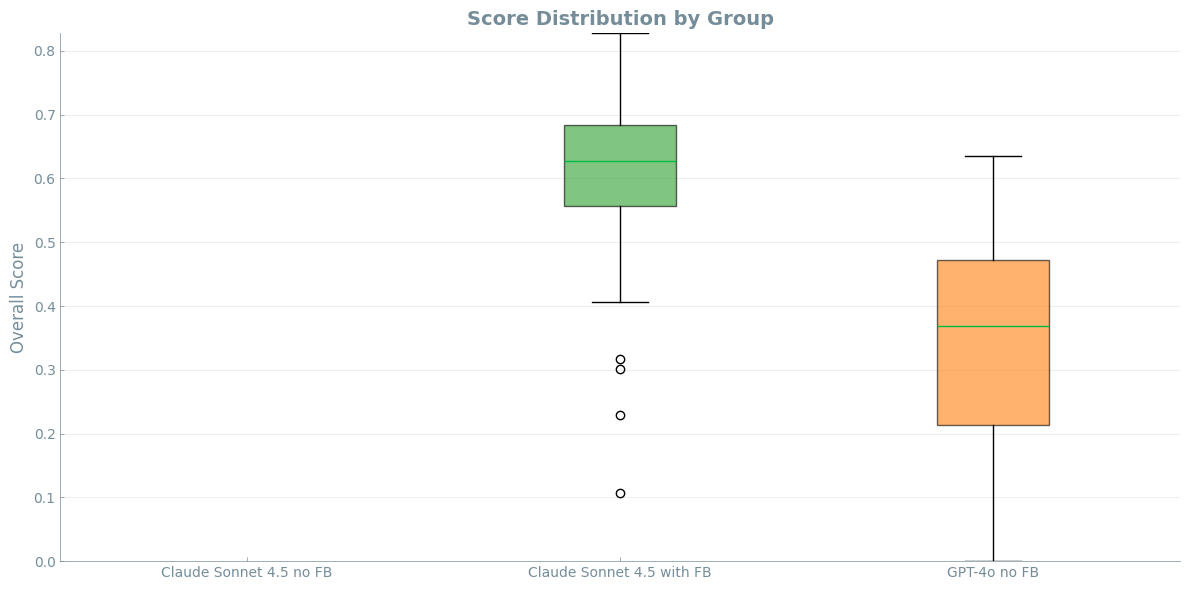

In [94]:
fig, ax = plt.subplots(figsize=(12, 6))

groups = sorted(set(run["group"] for run in RUNS))

data_by_group = []
colors_list = []
valid_groups = []

for group in groups:
    group_data = df_combined[df_combined["group"] == group]["overall_score"].to_numpy()
    if len(group_data) > 0:
        data_by_group.append(group_data)
        colors_list.append(get_group_color(group))
        valid_groups.append(group)

if data_by_group:
    bp = ax.boxplot(data_by_group, labels=valid_groups, patch_artist=True)

    for patch, color in zip(bp["boxes"], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_ylabel("Overall Score", fontsize=12)
    ax.set_title("Score Distribution by Group", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Best Networks per Group

In [95]:
def get_best_network_info(name, results, df):
    """Get the network from the best-scoring evaluation."""
    if len(df) == 0 or len(results) == 0:
        return None, 0, set()

    best_idx = df["overall_score"].idxmax()
    best_run_idx = df.loc[best_idx, "run_idx"] - 1
    best_score = df.loc[best_idx, "overall_score"]

    network = extract_reactions_list(results[best_run_idx]["data"])
    reactions = {r["equation"] for r in network} if network else set()

    return network, best_score, reactions


# Get best network for each run
best_networks = {}
for run in RUNS:
    name = run["name"]
    group = run["group"]
    network, score, reactions = get_best_network_info(
        name, all_results[name], all_dfs[name]
    )
    best_networks[name] = {
        "network": network,
        "score": score,
        "reactions": reactions,
        "group": group,
    }

# Find best network per group
best_per_group = {}
for name, info in best_networks.items():
    group = info["group"]
    if group not in best_per_group or info["score"] > best_per_group[group]["score"]:
        best_per_group[group] = {
            "name": name,
            "score": info["score"],
            "reactions": info["reactions"],
            "network": info["network"],
        }

print("=" * 80)
print("BEST NETWORK PER GROUP")
print("=" * 80)

for group, info in best_per_group.items():
    print(
        f"\n{group}: {info['name']} (Score = {info['score']:.4f}, {len(info['reactions'])} reactions)"
    )

BEST NETWORK PER GROUP

Claude Sonnet 4.5 with FB: Claude Sonnet 4.5 with FB 2 (Score = 0.8276, 7 reactions)

Claude Sonnet 4.5 no FB: Claude Sonnet 4.5 no FB 1 (Score = 0.6888, 9 reactions)

GPT-4o no FB: GPT-4o no FB 2 (Score = 0.6353, 7 reactions)


## Reaction Comparison Across Groups

In [96]:
# Get reactions from best network of each group
group_reactions = {group: info["reactions"] for group, info in best_per_group.items()}

# Common reactions (in ALL groups)
all_group_reactions = [r for r in group_reactions.values() if r]
if all_group_reactions:
    common_reactions = set.intersection(*all_group_reactions)
else:
    common_reactions = set()

print("=" * 80)
print("REACTION COMPARISON ACROSS GROUPS")
print("=" * 80)

print(f"\nCommon to ALL groups ({len(common_reactions)}):")
for rxn in sorted(common_reactions):
    print(f"    {rxn}")

# Unique reactions per group
print("\n\nUnique reactions per group:")
for group, reactions in group_reactions.items():
    other_reactions = set()
    for other_group, other_rxns in group_reactions.items():
        if other_group != group:
            other_reactions |= other_rxns

    unique = reactions - other_reactions
    if unique:
        print(f"\n  {group} only ({len(unique)}):")
        for rxn in sorted(unique):
            print(f"      + {rxn}")
    else:
        print(f"\n  {group}: (no unique reactions)")

REACTION COMPARISON ACROSS GROUPS

Common to ALL groups (2):
    RuII + hv -> RuII_ex
    RuII_ex -> RuII


Unique reactions per group:

  Claude Sonnet 4.5 with FB: (no unique reactions)

  Claude Sonnet 4.5 no FB only (6):
      + Ru2_dimer -> RuII + RuII
      + RuII + RuII -> Ru2_agg
      + RuIII + H2O -> RuII + O2
      + RuIII + RuIII -> Ru2_dimer
      + RuII_ex + S2O8 -> RuIII + SO4_rad
      + SO4_rad + H2O -> O2 + SO4_ion

  GPT-4o no FB only (1):
      + RuIII + RuII_ex -> Ru_inactive


## Reaction Presence Matrix (Best per Group)

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Serif, IBM Plex Sans, Roboto, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Sans Seri

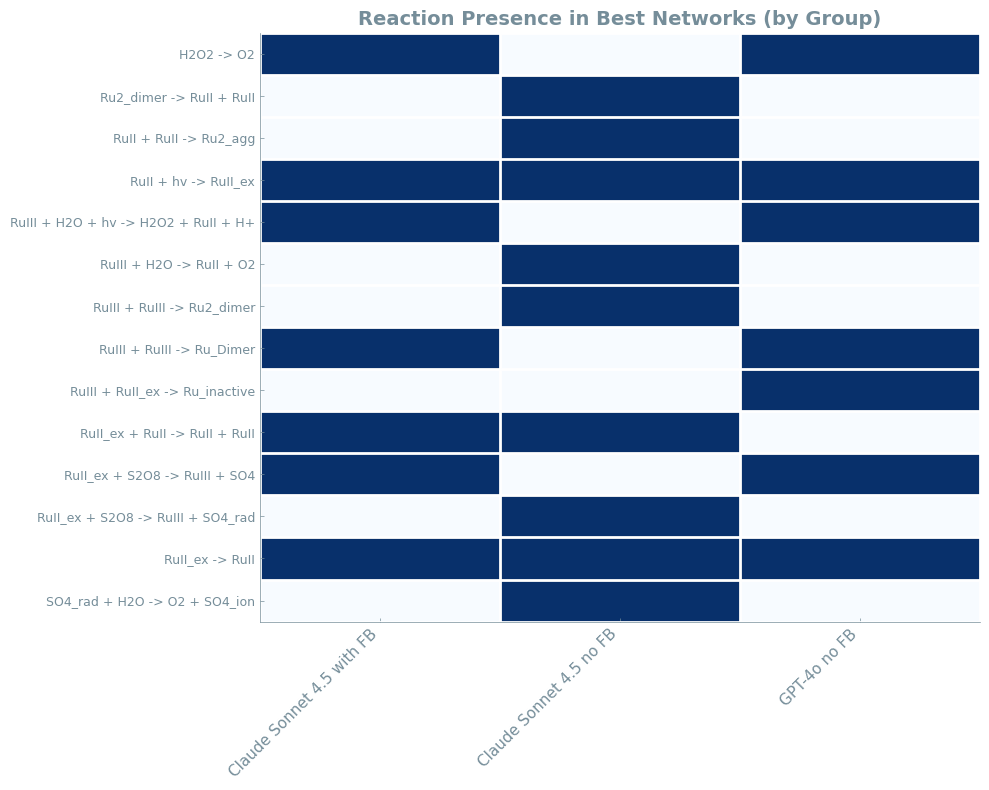

In [97]:
# Build presence matrix
all_reactions = set()
for reactions in group_reactions.values():
    all_reactions |= reactions

all_rxns = sorted(all_reactions)
groups = list(group_reactions.keys())

if all_rxns and groups:
    presence_matrix = np.zeros((len(all_rxns), len(groups)))
    for j, group in enumerate(groups):
        for i, rxn in enumerate(all_rxns):
            if rxn in group_reactions[group]:
                presence_matrix[i, j] = 1

    fig, ax = plt.subplots(
        figsize=(max(10, len(groups) * 2), max(8, len(all_rxns) * 0.5))
    )

    im = ax.imshow(presence_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, rotation=45, ha="right", fontsize=11)
    ax.set_yticks(range(len(all_rxns)))
    ax.set_yticklabels(all_rxns, fontsize=9)

    ax.set_title(
        "Reaction Presence in Best Networks (by Group)", fontsize=14, fontweight="bold"
    )

    ax.set_xticks(np.arange(-0.5, len(groups), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(all_rxns), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)

    plt.tight_layout()
    plt.show()
else:
    print("No reactions to display.")

## Detailed Best Network View

In [98]:
def print_network_details(group, info):
    """Print detailed network information."""
    print(f"\n{'=' * 70}")
    print(f"{group} - BEST: {info['name']} (Score: {info['score']:.4f})")
    print("=" * 70)

    network = info["network"]
    if not network:
        print("No network data available.")
        return

    print(f"Total reactions: {len(network)}\n")

    for i, rxn in enumerate(network, 1):
        rxn_type = rxn.get("type", "unknown")
        equation = rxn.get("equation", "N/A")
        description = rxn.get("description", "")

        if "k_range" in rxn:
            param_info = f"k: {rxn['k_range']}"
        elif "quantum_yield" in rxn:
            param_info = f"QY: {rxn['quantum_yield']}"
        else:
            param_info = ""

        type_str = "[light]" if rxn_type == "light" else "[dark] "
        print(f"{i:2d}. {type_str} {equation}")
        if description:
            print(f"       {description}")
        if param_info:
            print(f"       {param_info}")
        print()


for group, info in best_per_group.items():
    print_network_details(group, info)


Claude Sonnet 4.5 with FB - BEST: Claude Sonnet 4.5 with FB 2 (Score: 0.8276)
Total reactions: 7

 1. [light] RuII + hv -> RuII_ex
       Photoexcitation of Ru catalyst (k1)
       QY: [0.1, 1.0]

 2. [dark]  RuII_ex -> RuII
       Excited state decay (k8= 1/650ns)
       k: [1538461.5384615385, 1538461.5384615385]

 3. [dark]  RuII_ex + S2O8 -> RuIII + SO4
       Oxidative quenching (k7)
       k: [1.0, 60.0]

 4. [light] RuIII + H2O + hv -> H2O2 + RuII + H+
       Light-driven water oxidation (k2)
       QY: [0.1, 1.0]

 5. [dark]  RuIII + RuIII -> Ru_Dimer
       Dimer formation (k3)
       k: [0.01, 5]

 6. [dark]  H2O2 -> O2
       H2O2 decomposition to O2 (k5)
       k: [0.001, 0.5]

 7. [dark]  RuII_ex + RuII -> RuII + RuII
       Excited state quenching
       k: [50000.0, 200000.0]


Claude Sonnet 4.5 no FB - BEST: Claude Sonnet 4.5 no FB 1 (Score: 0.6888)
Total reactions: 9

 1. [light] RuII + hv -> RuII_ex
       Photoexcitation
       QY: [0.05, 0.9]

 2. [dark]  RuII_ex -

## Group Winner Summary

In [99]:
print("=" * 80)
print("GROUP WINNER SUMMARY")
print("=" * 80)

metrics = [
    ("Best Score", True),
    ("Best Ru", True),
    ("Best S2O8", True),
    ("Best Irradiance", True),
    ("Best pH", True),
    ("Efficiency (%)", True),
    ("Best Network Size", False),  # Lower is better
]

groups = group_summary.index.tolist()
group_wins = {g: 0 for g in groups}

for metric, higher_better in metrics:
    values = {g: group_summary.loc[g, metric] for g in groups}

    if higher_better:
        winner = max(values, key=values.get)
    else:
        winner = min(values, key=values.get)

    group_wins[winner] += 1

    print(f"\n{metric} {'(higher=better)' if higher_better else '(lower=better)'}:")
    sorted_values = sorted(
        values.items(), key=lambda x: -x[1] if higher_better else x[1]
    )
    for g, val in sorted_values:
        marker = " <-- WINNER" if g == winner else ""
        print(f"    {g}: {val:.4f}{marker}")

# Final tally
print("\n" + "=" * 80)
print("FINAL GROUP TALLY")
print("=" * 80)

for g, count in sorted(group_wins.items(), key=lambda x: -x[1]):
    print(f"    {g}: {count} wins")

overall_winner = max(group_wins, key=group_wins.get)
print(f"\nOVERALL WINNING GROUP: {overall_winner}")

GROUP WINNER SUMMARY

Best Score (higher=better):
    Claude Sonnet 4.5 with FB: 0.8276 <-- WINNER
    Claude Sonnet 4.5 no FB: 0.6888
    GPT-4o no FB: 0.6353

Best Ru (higher=better):
    Claude Sonnet 4.5 with FB: 0.9642 <-- WINNER
    Claude Sonnet 4.5 no FB: 0.8371
    GPT-4o no FB: 0.7095

Best S2O8 (higher=better):
    Claude Sonnet 4.5 no FB: 0.9917 <-- WINNER
    Claude Sonnet 4.5 with FB: 0.7863
    GPT-4o no FB: 0.7752

Best Irradiance (higher=better):
    Claude Sonnet 4.5 with FB: 0.9973 <-- WINNER
    GPT-4o no FB: 0.8279
    Claude Sonnet 4.5 no FB: 0.8174

Best pH (higher=better):
    Claude Sonnet 4.5 no FB: 0.7474 <-- WINNER
    GPT-4o no FB: 0.6310
    Claude Sonnet 4.5 with FB: 0.6137

Efficiency (%) (higher=better):
    GPT-4o no FB: 33.1545 <-- WINNER
    Claude Sonnet 4.5 with FB: 33.0392
    Claude Sonnet 4.5 no FB: 18.9244

Best Network Size (lower=better):
    Claude Sonnet 4.5 no FB: 5.0000 <-- WINNER
    GPT-4o no FB: 6.0000
    Claude Sonnet 4.5 with FB: 7.

## Export Data

In [100]:
df_combined.to_csv("grouped_run_comparison.csv", index=False)
print("Saved combined data to grouped_run_comparison.csv")

summary_df.to_csv("grouped_run_summary.csv", index=False)
print("Saved run summary to grouped_run_summary.csv")

group_summary.to_csv("group_summary.csv")
print("Saved group summary to group_summary.csv")

Saved combined data to grouped_run_comparison.csv
Saved run summary to grouped_run_summary.csv
Saved group summary to group_summary.csv
